# Figuring Out What is Wrong with the Value Function

Plot two checkpoints to check if any training occurs.

In [2]:
# PATH = '../../scratch/aorl2/2026-04-03-01/2026-04-03-01.e41dc59d520a81aab8c1bbc9a7e37bef9d23933c1c815333d0945caf62e4dd45/'

# PATH = '../../scratch/aorl2/2026-04-06-02/2026-04-06-02.5516028add7c89cb238abb80019c6cfd15df1f80fa2cfac6a7cd16df2d4fc2e1'
# PATH = '../../scratch/aorl2/2026-04-06-02/2026-04-06-02.c4e081058d94903e288f2a44784058070f236452c80967eb1e73ad1c8948cd52'
# PATH = '../../scratch/aorl2/2026-04-06-02/2026-04-06-02.4b79ff67b8c71edfd7af9c159d8540bdd41c1b4d69b8a1709528f47462eb419d'

# PATH = '../../scratch/aorl2/2026-04-07-00/2026-04-07-00.cf299c515a56efb2ec6b8eb1906b159202c29440bb9b43fcf6c2e56a06b10ddc'
# FIRST_CKPT_NUM = 900000
# SECOND_CKPT_NUM = 1000000

PATH = '../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c/'

FIRST_CKPT_NUM = 900000
SECOND_CKPT_NUM = 1000000

Are the checkpoints even correct? Am I mising FQL and GCFQL parameters?

**Yes. Doesn't load properly if different types.**

In [3]:
import json
import os

import numpy as np

from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset, CGCDataset
from utils.flax_utils import restore_agent

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [7]:
saved_flags['agent']

{'action_dim': None,
 'actor_geom_sample': True,
 'actor_hidden_dims': [1024, 1024, 1024, 1024],
 'actor_layer_norm': True,
 'actor_p_curgoal': 0.0,
 'actor_p_randomgoal': 0.5,
 'actor_p_trajgoal': 0.5,
 'agent_name': 'dqc',
 'backup_horizon': 25,
 'batch_size': 256,
 'best_of_n': 4,
 'dataset_class': 'CGCDataset',
 'discount': 0.995,
 'distill_method': 'expectile',
 'flow_steps': 10,
 'gc_negative': False,
 'goal_dim': None,
 'goal_proposer_loss_weight': 1.0,
 'implicit_backup_type': 'quantile',
 'kappa_b': 0.5,
 'kappa_d': 0.8,
 'layer_norm': True,
 'lr': 0.0003,
 'num_qs': 10,
 'ob_dims': None,
 'policy_chunk_size': 1,
 'q_agg': 'mean',
 'subgoal_steps': 25,
 'tau': 0.005,
 'train_goal_proposer': True,
 'use_chunk_critic': True,
 'value_geom_sample': False,
 'value_hidden_dims': [1024, 1024, 1024, 1024],
 'value_p_curgoal': 0.2,
 'value_p_randomgoal': 0.3,
 'value_p_trajgoal': 0.5}

In [8]:
flags_path = os.path.join(PATH, 'flags.json')
with open(flags_path, 'r') as f:
    saved_flags = json.load(f)

agent_config = saved_flags['agent']
dataset_class_name = agent_config.get('dataset_class', 'GCDataset')
dataset_class = {
    'GCDataset': GCDataset,
    'HGCDataset': HGCDataset,
    'CGCDataset': CGCDataset,
}[dataset_class_name]

dataset_path = os.path.join(PATH, 'data-100000.npz')
dataset_npz = np.load(dataset_path)
train_dataset = dataset_class(Dataset.create(**dict(dataset_npz)), config=agent_config)

seed = saved_flags.get('seed', 0)
example_batch = train_dataset.sample(1)

first_agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
first_agent = restore_agent(first_agent, PATH, FIRST_CKPT_NUM)

second_agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
second_agent = restore_agent(second_agent, PATH, SECOND_CKPT_NUM)

print(f'Restored first_agent from checkpoint {FIRST_CKPT_NUM}')
print(f'Restored second_agent from checkpoint {SECOND_CKPT_NUM}')

Restored from ../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c//params_900000.pkl
Restored from ../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c//params_1000000.pkl
Restored first_agent from checkpoint 900000
Restored second_agent from checkpoint 1000000


In [9]:
from tqdm import tqdm

all_cells = {}

for ob in tqdm(train_dataset.dataset['observations']):
    key = (np.floor(ob[0]), np.floor(ob[1]))
    if key in all_cells:
        all_cells[key] += 1
    else:
        all_cells[key] = 1

all_cell_points = np.asarray(list(all_cells.keys()))

100%|██████████| 2000000/2000000 [00:04<00:00, 421198.40it/s]


In [10]:
goal = np.asarray([20, 8])
# goal = np.asarray([11, 15])

In [12]:
all_cell_points

array([[-1.,  8.],
       [ 0.,  8.],
       [ 0.,  7.],
       ...,
       [ 8.,  0.],
       [37., 25.],
       [37., 22.]], dtype=float32)

In [13]:
ob

array([-3.30918819e-01,  1.73225651e+01, -1.43846765e-01,  5.37877500e-01,
        1.85681190e-02, -3.51119936e-01, -9.22396958e-01, -1.84962201e+00,
        4.39099222e-02, -1.82547823e-01, -1.11640823e+00, -1.67924806e-01,
       -7.79628336e-01,  2.14965463e-01, -2.66795325e+00, -8.85929644e-01,
        8.81495774e-01, -1.52986610e+00, -1.50937879e+00, -2.80273765e-01,
       -1.05306327e+00,  8.21021020e-01,  2.61441559e-01,  4.90537882e-01,
        1.42267570e-01,  4.67555188e-02, -1.61357626e-01, -3.22462499e-01,
        7.74715515e-03, -3.80149782e-01, -2.15593278e-01, -5.21621406e-01,
        1.72737271e-01,  3.42925131e-01, -6.48841381e-01, -2.87045717e-01,
        7.27588654e-01,  6.35835767e-01,  2.57541567e-01,  1.84092641e+00,
        1.69838893e+00, -3.59588653e-01,  1.26121926e+00, -1.28510863e-01,
        1.05721557e+00,  1.92533994e+00,  8.48920822e+00,  1.01170070e-01,
        1.53804088e+00, -1.41053700e+00, -5.07360458e+00,  1.93717682e+00,
       -9.36369419e+00, -

In [90]:
# for i in range(1000):
ob = train_dataset.dataset['observations'][11201]
all_cell_obs = np.repeat(ob[None], len(all_cell_points), axis=0)
# all_cell_obs = train_dataset.dataset['observations'][:100000].copy()

for i in range(len(all_cell_points)):
    p = all_cell_points[i, ...]
    all_cell_obs[i, 0] = p[0]
    all_cell_obs[i, 1] = p[1]

all_goals = np.repeat(goal[None], len(all_cell_obs), axis=0)
all_vs = first_agent.network.select('value')(all_cell_obs, all_goals)

# all_vs = np.log(all_vs + 1e-8)

# if not (all_vs == all_vs[0]).all():
#     print(i)
#     break

In [91]:
all_cell_obs.shape

(736, 69)

In [92]:
import matplotlib.pyplot as plt

In [93]:
(all_vs == all_vs[0]).all()

Array(False, dtype=bool)

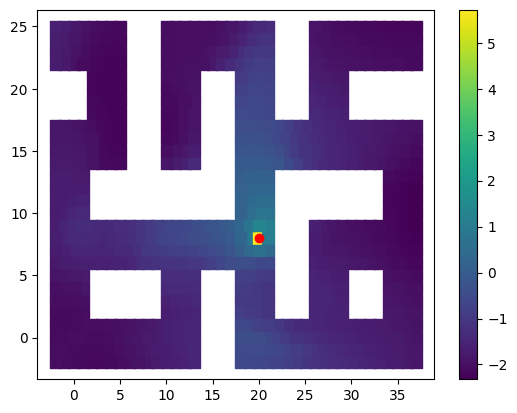

In [94]:
m = plt.scatter(x=all_cell_obs[..., 0], y=all_cell_obs[..., 1], s=68, marker='s', c=all_vs, cmap='viridis')
plt.scatter(x=goal[0], y=goal[1], c='red')
plt.colorbar(m)
plt.show()

NameError: name 'env' is not defined

In [18]:
all_goals = np.repeat(goal[None], len(all_cell_points), axis=0)
all_vs = second_agent.network.select('value')(all_cell_points, all_goals)

m = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=68, marker='s', c=all_vs, cmap='viridis')
plt.scatter(x=goal[0], y=goal[1], c='red')
plt.colorbar(m)
plt.show()

ScopeParamShapeError: Initializer expected to generate shape (71, 1024) but got shape (4, 1024) instead for parameter "kernel" in "/modules_value/value_net/Dense_0". (https://flax.readthedocs.io/en/latest/api_reference/flax.errors.html#flax.errors.ScopeParamShapeError)

In [ ]:
first_agent.network.params.keys()

dict_keys(['modules_critic', 'modules_target_critic', 'modules_value', 'modules_actor_bc_flow', 'modules_actor_onestep_flow', 'modules_goal_proposer'])

In [ ]:
first_value_params = first_agent.network.params['modules_value']
second_value_params = second_agent.network.params['modules_value']


In [ ]:
import jax

jax.tree_util.tree_map(lambda x: x.shape, first_value_params)


{'value_net': {'Dense_0': {'bias': (512,), 'kernel': (4, 512)},
  'Dense_1': {'bias': (512,), 'kernel': (512, 512)},
  'Dense_2': {'bias': (512,), 'kernel': (512, 512)},
  'Dense_3': {'bias': (512,), 'kernel': (512, 512)},
  'Dense_4': {'bias': (1,), 'kernel': (512, 1)},
  'LayerNorm_0': {'bias': (512,), 'scale': (512,)},
  'LayerNorm_1': {'bias': (512,), 'scale': (512,)},
  'LayerNorm_2': {'bias': (512,), 'scale': (512,)},
  'LayerNorm_3': {'bias': (512,), 'scale': (512,)}}}

In [ ]:
import numpy as np

first_value_weights = jax.tree_util.tree_map(np.array, first_value_params)
second_value_weights = jax.tree_util.tree_map(np.array, second_value_params)


In [ ]:
first_value_weights

{'value_net': {'Dense_0': {'bias': array([ 7.48269200e-01, -3.82688753e-02, -5.30771799e-02, -1.04460111e-02,
           7.11557448e-01, -4.82152626e-02,  2.67699093e-01,  6.34880245e-01,
           3.66841644e-01,  4.03180927e-01,  3.77719432e-01, -1.72973335e-01,
          -3.27829957e-01, -1.71173260e-01,  1.97290257e-02,  7.99201190e-01,
          -7.46650100e-02,  1.70959592e-01,  7.32264578e-01, -1.62139431e-01,
          -1.12137413e-02, -4.75583263e-02, -4.71448526e-02, -4.76620972e-01,
          -1.13833003e-01,  1.02267511e-01, -3.58063817e-01, -1.71246096e-01,
           1.50325313e-01,  4.37338233e-01,  2.46149942e-01, -3.84714216e-01,
           4.37305868e-01,  4.08156484e-01, -4.00154680e-01,  3.18400055e-01,
          -1.10000744e-01,  2.10910425e-01, -4.62931208e-02, -1.27711268e-02,
           5.27437508e-01,  3.28869432e-01, -2.52104938e-01,  3.48335296e-01,
          -2.52381414e-02, -1.63693931e-02,  6.26937971e-02,  2.18896851e-01,
           1.36756962e-02, -5.45

In [ ]:
second_value_weights

{'value_net': {'Dense_0': {'bias': array([ 0.8112534 ,  0.0109616 , -0.01181942,  0.00991332,  0.8007771 ,
          -0.00466639,  0.2614136 ,  0.75678265,  0.39561713,  0.40720078,
           0.4616339 , -0.13688242, -0.39545768, -0.13977677,  0.08274627,
           0.86684304, -0.0631014 ,  0.23510805,  0.8241924 , -0.08466907,
           0.04502248,  0.04024237, -0.02301896, -0.42028144, -0.09459115,
           0.08780497, -0.3964161 , -0.11639791,  0.18826908,  0.48264217,
           0.305883  , -0.4311887 ,  0.5000506 ,  0.508213  , -0.4625831 ,
           0.39209533, -0.068699  ,  0.30960882,  0.01734787,  0.05819976,
           0.52737635,  0.32517898, -0.21134238,  0.3469165 ,  0.05414136,
          -0.03476121,  0.11520287,  0.2626907 ,  0.06895597, -0.6247938 ,
          -0.5454411 ,  0.11300348, -0.4968022 ,  0.04286353, -0.00398103,
           0.08397511,  0.24996828,  0.02487884, -0.11414887,  0.07068536,
           0.31369764,  0.35590586,  0.25481835,  0.02654807,  0.137

In [ ]:
(first_value_weights['value_net']['Dense_0']['bias'] == second_value_weights['value_net']['Dense_0']['bias'])

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [ ]:
train_dataset.dataset['observations'][..., :2]

array([[-0.07952569,  8.261749  ],
       [-0.07690136,  8.260354  ],
       [-0.07960749,  8.264774  ],
       ...,
       [-0.3887374 , 17.31017   ],
       [-0.36054185, 17.32144   ],
       [-0.33091882, 17.322565  ]], dtype=float32)

In [ ]:
train_dataset.dataset['oracle_reps']

array([[-0.07952569,  8.261749  ],
       [-0.07690136,  8.260354  ],
       [-0.07960749,  8.264774  ],
       ...,
       [-0.3887374 , 17.31017   ],
       [-0.36054185, 17.32144   ],
       [-0.33091882, 17.322565  ]], dtype=float32)

In [ ]:
(train_dataset.dataset['observations'][..., :2] == train_dataset.dataset['oracle_reps']).all()

True

## Checking the Critic

[37.775333 13.013098]
[20  8]


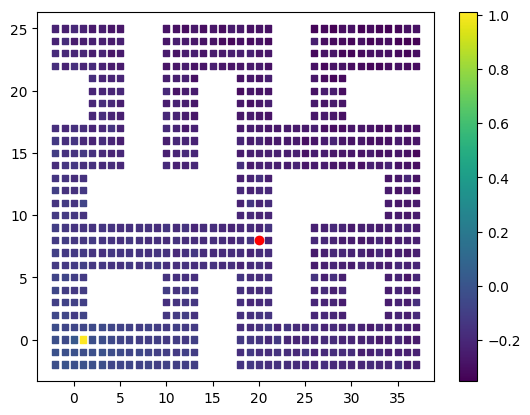

In [ ]:
ob = train_dataset.dataset['observations'][1100]
rng = jax.random.PRNGKey(0)
print(ob[:2])
print(goal)

all_goals = np.repeat(goal[None], len(all_cell_points), axis=0)
obs = []

for xy in all_cell_points:
    new_ob = ob.copy()
    new_ob[0] = xy[0]
    new_ob[1] = xy[1]
    obs.append(new_ob)

obs = np.asarray(obs)

actions = second_agent.sample_actions(obs, all_goals, rng)
all_vs = second_agent.network.select('critic')(obs, actions, all_goals)
all_vs = all_vs.mean(axis=0)

m = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=20, marker='s', c=all_vs, cmap='viridis')
plt.scatter(x=goal[0], y=goal[1], c='red')
plt.colorbar(m)
plt.show()